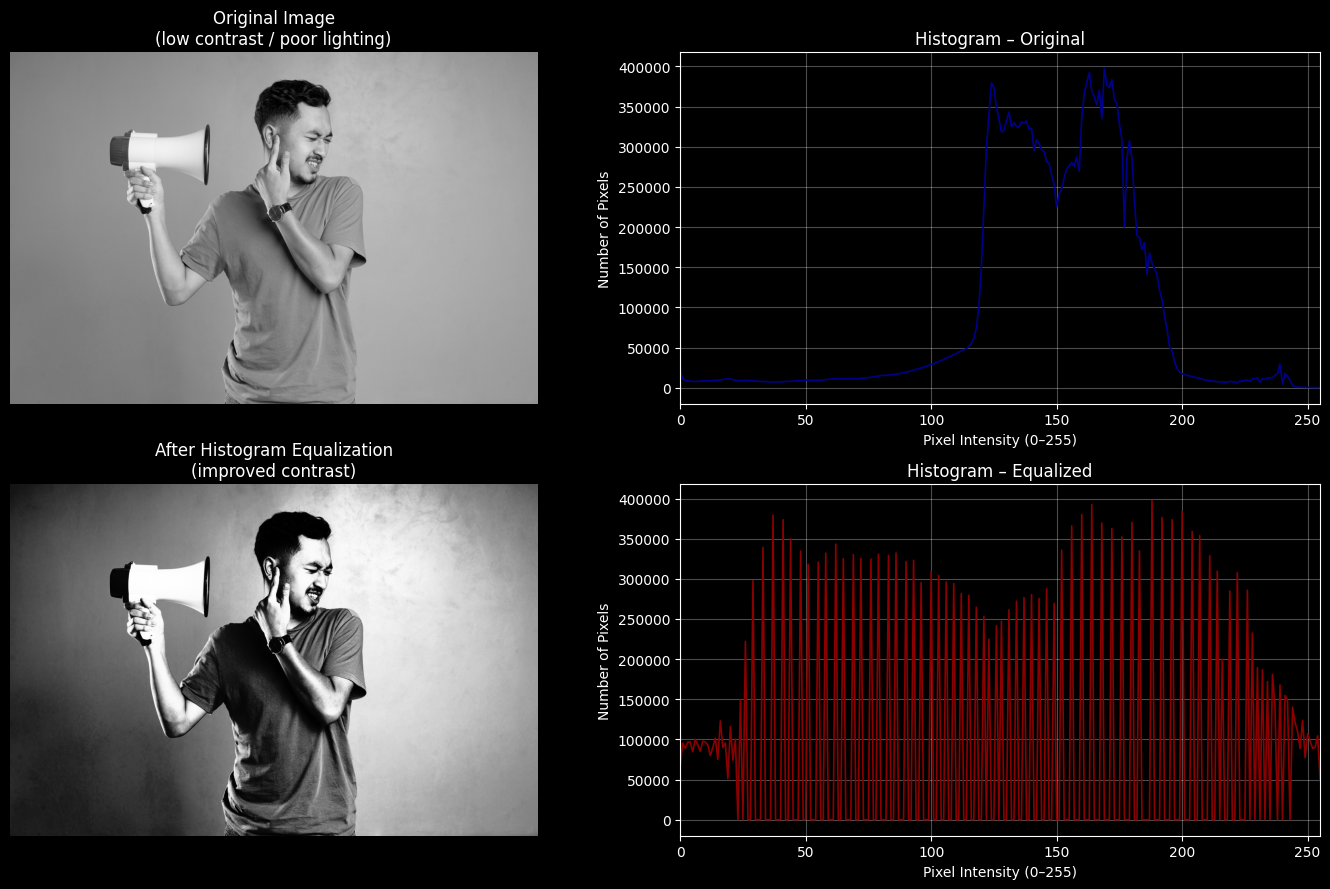

Side-by-side comparison saved as: histogram_equalization_result.jpg


In [3]:
# Task 1:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'images/test_noise_image.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not load image at '{image_path}'")
    print("Please check the file path and try again.")
else:
    img_eq = cv2.equalizeHist(img)

    hist_orig = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist_eq   = cv2.calcHist([img_eq], [0], None, [256], [0, 256])

    plt.figure(figsize=(14, 9))

    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image\n(low contrast / poor lighting)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(img_eq, cmap='gray')
    plt.title('After Histogram Equalization\n(improved contrast)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.plot(hist_orig, color='darkblue', linewidth=1.2)
    plt.title('Histogram – Original')
    plt.xlabel('Pixel Intensity (0–255)')
    plt.ylabel('Number of Pixels')
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(hist_eq, color='darkred', linewidth=1.2)
    plt.title('Histogram – Equalized')
    plt.xlabel('Pixel Intensity (0–255)')
    plt.ylabel('Number of Pixels')
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    comparison = np.hstack((img, img_eq))
    cv2.imwrite('images/histogram_equalization_result.jpg', comparison)
    print("Side-by-side comparison saved as: histogram_equalization_result.jpg")

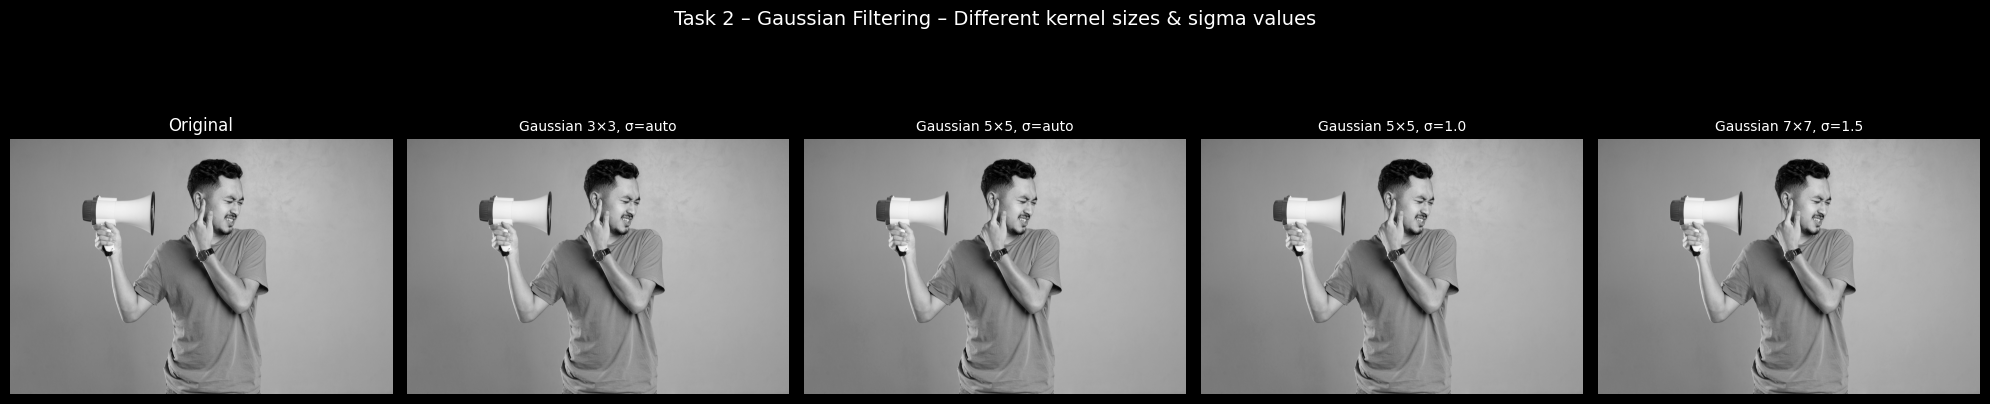

In [4]:
# Task 2
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'images/test_noise_image.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"ERROR: Cannot load image → check path: {image_path}")
else:
    configs = [
        {"ksize": (3,3),  "sigma": 0,   "label": "Gaussian 3×3, σ=auto"},
        {"ksize": (5,5),  "sigma": 0,   "label": "Gaussian 5×5, σ=auto"},
        {"ksize": (5,5),  "sigma": 1.0, "label": "Gaussian 5×5, σ=1.0"},
        {"ksize": (7,7),  "sigma": 1.5, "label": "Gaussian 7×7, σ=1.5"},
    ]

    results = {}
    for cfg in configs:
        blurred = cv2.GaussianBlur(
            img,
            ksize=cfg["ksize"],
            sigmaX=cfg["sigma"],
            sigmaY=cfg["sigma"]
        )
        results[cfg["label"]] = blurred
    n_plots = len(results) + 1
    # n_plots = len(results) + 2
    plt.figure(figsize=(4 * n_plots, 5))

    plt.subplot(1, n_plots, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    col = 2
    for label, img_blur in results.items():
        plt.subplot(1, n_plots, col)
        plt.imshow(img_blur, cmap='gray')
        plt.title(label, fontsize=10)
        plt.axis('off')
        col += 1


    plt.suptitle("Task 2 – Gaussian Filtering – Different kernel sizes & sigma values", fontsize=14)
    plt.tight_layout()
    plt.show()


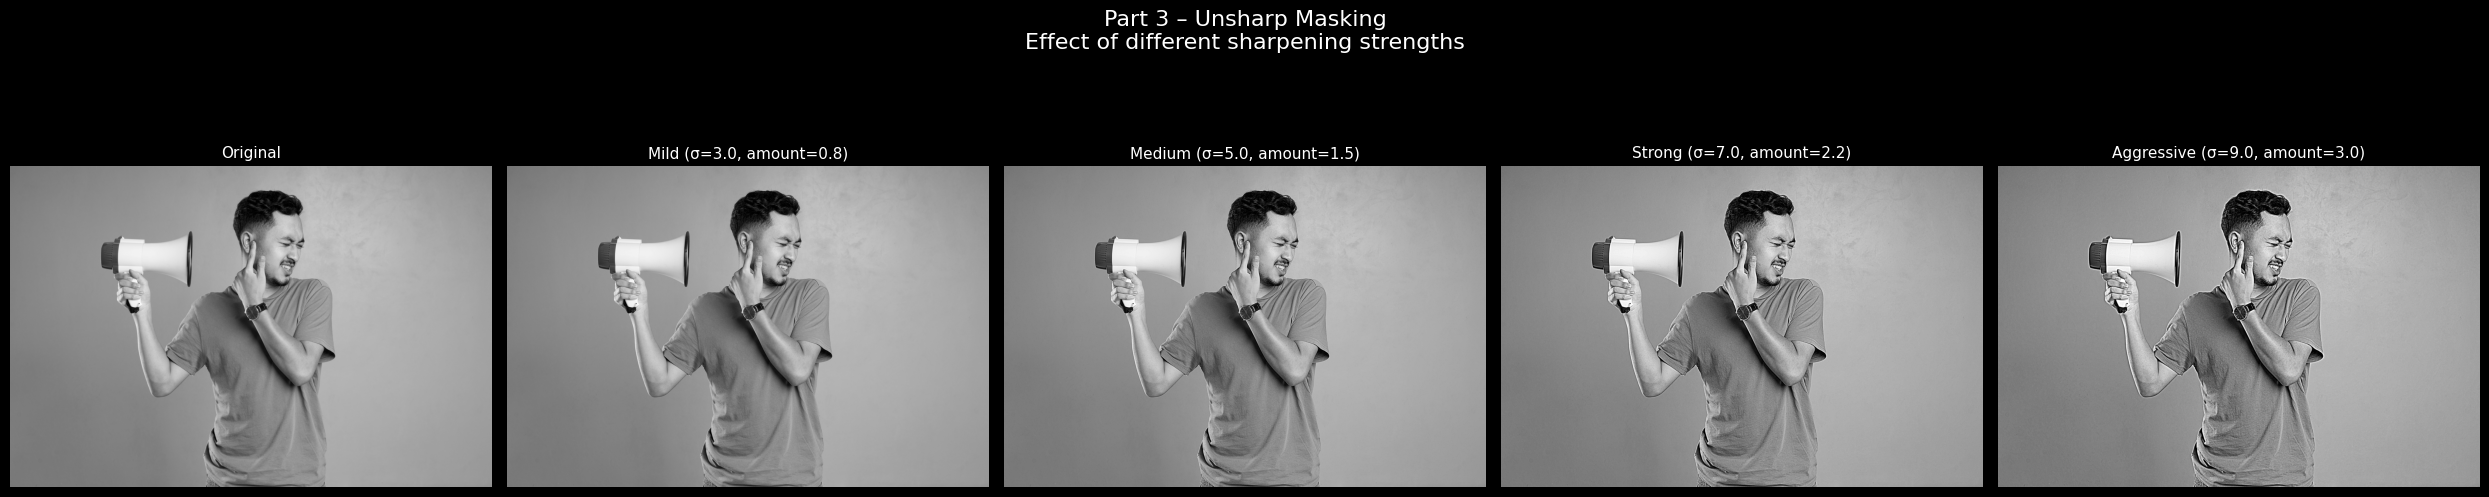

Comparison saved as: task3_unsharp_masking_comparison.jpg


In [7]:
#Task 3
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'images/test_noise_image.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Could not load image. Check path:", image_path)
else:
    experiments = [
        {"sigma": 3.0, "amount": 0.8,  "label": "Mild (σ=3.0, amount=0.8)"},
        {"sigma": 5.0, "amount": 1.5,  "label": "Medium (σ=5.0, amount=1.5)"},
        {"sigma": 7.0, "amount": 2.2,  "label": "Strong (σ=7.0, amount=2.2)"},
        {"sigma": 9.0, "amount": 3.0,  "label": "Aggressive (σ=9.0, amount=3.0)"},
    ]

    results = {"Original": img}

    for exp in experiments:
        sigma  = exp["sigma"]
        amount = exp["amount"]

        blurred = cv2.GaussianBlur(img, ksize=(0, 0), sigmaX=sigma)

        high_pass = img.astype(np.float32) - blurred.astype(np.float32)

        sharpened = img.astype(np.float32) + amount * high_pass

        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

        results[exp["label"]] = sharpened

    plt.figure(figsize=(5 * len(results), 6))

    for i, (title, res_img) in enumerate(results.items(), 1):
        plt.subplot(1, len(results), i)
        plt.imshow(res_img, cmap='gray')
        plt.title(title, fontsize=11)
        plt.axis('off')

    plt.suptitle("Part 3 – Unsharp Masking\nEffect of different sharpening strengths", fontsize=16)
    plt.tight_layout()
    plt.show()

    comparison = np.hstack(list(results.values()))
    cv2.imwrite("images/task3_unsharp_masking_comparison.jpg", comparison)
    print("Comparison saved as: task3_unsharp_masking_comparison.jpg")